# Processamento de Linguagem Natural (PLN)

Alunas:
- Leila Maria Biggi de Souza Cavalcante
- Maria Antonia Ribeiro Ramos

## Instalação e imports

In [1]:
# Rode esta célula uma vez para instalar a stack no kernel atual
%pip install numpy pandas nltk spacy scikit-learn kagglehub matplotlib bertopic gensim
!python -m spacy download en_core_web_sm

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   - -------------------------------------- 1.0/24.4 MB 8.6 MB/s eta 0:00:03
   -- ------------------------------------- 1.3/24.4 MB 583.1 kB/s eta 0:00:40
   ----- ---------------------------------- 3.1/24.4 MB 1.5 MB/s eta 0:00:15
   -------- ------------------------------- 5.2/24.4 MB 2.3 MB/s eta 0:00:09
   -------- ------------------------------- 5.2/24.4 MB 2.3 MB/s eta 0:00:09
   -

In [2]:
import string
from collections import Counter
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import re
import sklearn
import spacy
from bertopic import BERTopic
from nltk.stem import PorterStemmer
from sklearn.decomposition import NMF, LatentDirichletAllocation, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("nltk", nltk.__version__)
print("spacy", spacy.__version__)
print("scikit-learn", sklearn.__version__)
print("re", re.__version__)
print("matplotlib", plt.matplotlib.__version__)

numpy 2.5.2
pandas 3.0.5
nltk 3.10.3
spacy 3.8.16
scikit-learn 1.9.0
re 2.2.1
matplotlib 3.11.1


In [3]:
# Language resources (run once)
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

# spaCy English model. If this fails, install in the terminal:
# python -m spacy download en_core_web_sm
try:
    nlp = spacy.load("en_core_web_sm")
    print("spaCy: en_core_web_sm loaded")
except OSError:
    print("en_core_web_sm is not installed yet.")

stopwords_en = set(nltk.corpus.stopwords.words("english"))
print("NLTK English stopwords:", len(stopwords_en))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Leila\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Leila\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Leila\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Leila\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


spaCy: en_core_web_sm loaded
NLTK English stopwords: 198


In [4]:
path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Leila\.cache\kagglehub\datasets\hgultekin\bbcnewsarchive\versions\1


## Base e pré-processamento

Reutilizamos a **BBC News Archive** e os mesmos passos da Lista 1 (questões 5 e 6): tokens sem números e pontuação, minúsculas, remoção de stopwords e stemming. O texto pré-processado (`text_preproc`) é o que as questões abaixo usam nas representações vetoriais.

In [5]:
if "path" not in globals():
    path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

news = pd.read_csv(Path(path) / "bbc-news-data.csv", sep="\t")
stemmer = PorterStemmer()


def preprocess(text: str) -> list[str]:
    """Tokenize, drop tokens with digits, lowercase and strip punctuation."""
    tokens = nltk.word_tokenize(str(text))
    tokens = [token.lower() for token in tokens]
    tokens = [token for token in tokens if not any(ch.isdigit() for ch in token)]
    tokens = [token.translate(str.maketrans("", "", string.punctuation)) for token in tokens]
    return [token for token in tokens if token]


news["tokens"] = news["content"].map(preprocess)
news["tokens_nostop"] = news["tokens"].map(
    lambda tokens: [token for token in tokens if token not in stopwords_en]
)
news["stems"] = news["tokens_nostop"].map(
    lambda tokens: [stemmer.stem(token) for token in tokens]
)
news["text_preproc"] = news["stems"].map(lambda tokens: " ".join(tokens))

print(f"Textos na base: {len(news)}")
print("Categorias:", sorted(news["category"].unique()))
print(news["category"].value_counts().to_string())
display(news[["filename", "category", "title", "text_preproc"]].head())

Textos na base: 2225
Categorias: ['business', 'entertainment', 'politics', 'sport', 'tech']
category
sport            511
business         510
politics         417
tech             401
entertainment    386


,filename,category,title,text_preproc
0,001.txt,business,Ad sales boost Time Warner profit,quarterli profit us media giant timewarn jump ...
1,002.txt,business,Dollar gains on Greenspan speech,dollar hit highest level euro almost three mon...
2,003.txt,business,Yukos unit buyer faces loan claim,owner embattl russian oil giant yuko ask buyer...
3,004.txt,business,High fuel prices hit BA's profits,british airway blame high fuel price drop prof...
4,005.txt,business,Pernod takeover talk lifts Domecq,share uk drink food firm alli domecq risen spe...


## Exercícios

#### 1. Escolha 5 documentos da sua base pré-processada, e determine seu documento mais parecido, dentre todos os documentos da base (não pode ser ele mesmo), usando:
a) Representação vetorial CountVectorizer com similaridade do cosseno;  
b) Representação vetorial TF-IDF com similaridade do cosseno.

Justifique, para cada par de documentos mais parecidos, porque cada representação considerou o par semelhante.

In [6]:
# Cinco documentos-consulta: o primeiro de cada categoria da BBC News.
# Assim dá para ver se a similaridade recupera o mesmo tópico editorial
# e onde CountVectorizer e TF-IDF divergem.
query_idx = news.groupby("category", sort=True).head(1).index.tolist()

print("Documentos escolhidos:")
display(news.loc[query_idx, ["filename", "category", "title"]].reset_index(drop=True))

# Vocabulário sobre o corpus já pré-processado (Lista 1). Sem stop_words
# extras: stopwords e stemming já foram aplicados.
count_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()
X_count = count_vectorizer.fit_transform(news["text_preproc"])
X_tfidf = tfidf_vectorizer.fit_transform(news["text_preproc"])

print(f"\nCountVectorizer: {X_count.shape[0]} docs × {X_count.shape[1]} termos")
print(f"TF-IDF:          {X_tfidf.shape[0]} docs × {X_tfidf.shape[1]} termos")


def similar_pairs(X, vectorizer, n_terms=8):
    """Para cada consulta, o vizinho de maior cosseno (exceto ele mesmo)
    e os termos que mais pesam no produto interno dos dois vetores."""
    vocab = vectorizer.get_feature_names_out()
    rows = []
    for i in query_idx:
        sims = cosine_similarity(X[i], X).ravel()
        sims[i] = -1
        j = int(np.argmax(sims))

        weights_i = X[i].toarray().ravel()
        weights_j = X[j].toarray().ravel()
        contrib = weights_i * weights_j
        order = np.argsort(contrib)[::-1][:n_terms]
        terms = [vocab[k] for k in order if contrib[k] > 0]

        rows.append({
            "consulta": news.loc[i, "title"],
            "cat. consulta": news.loc[i, "category"],
            "mais parecido": news.loc[j, "title"],
            "cat. vizinho": news.loc[j, "category"],
            "cosseno": round(float(sims[j]), 4),
            "termos que mais pesam": ", ".join(terms),
        })
    table = pd.DataFrame(rows)
    table.index = table.index + 1
    return table


print("\na) CountVectorizer + similaridade do cosseno")
display(similar_pairs(X_count, count_vectorizer))

print("\nb) TF-IDF + similaridade do cosseno")
display(similar_pairs(X_tfidf, tfidf_vectorizer))


Documentos escolhidos:


,filename,category,title
0,001.txt,business,Ad sales boost Time Warner profit
1,001.txt,entertainment,Gallery unveils interactive tree
2,001.txt,politics,Labour plans maternity pay rise
3,001.txt,sport,Claxton hunting first major medal
4,001.txt,tech,Ink helps drive democracy in Asia



CountVectorizer: 2225 docs × 21242 termos
TF-IDF:          2225 docs × 21242 termos

a) CountVectorizer + similaridade do cosseno


,consulta,cat. consulta,mais parecido,cat. vizinho,cosseno,termos que mais pesam
1,Ad sales boost Time Warner profit,business,Ask Jeeves tips online ad revival,business,0.3133,"profit, quarter, advertis, sale, revenu, inter..."
2,Gallery unveils interactive tree,entertainment,New Year's texting breaks record,tech,0.1869,"text, messag, year, sent, london, last, also"
3,Labour plans maternity pay rise,politics,Lib Dems unveil women's manifesto,politics,0.4652,"said, women, pay, would, matern, plan, month, new"
4,Claxton hunting first major medal,sport,Gardener battles to narrow win,sport,0.4176,"european, titl, time, claxton, second, jump, m..."
5,Ink helps drive democracy in Asia,tech,February poll claim 'speculation',politics,0.2566,"elect, februari, poll, parliamentari, new, gov..."



b) TF-IDF + similaridade do cosseno


,consulta,cat. consulta,mais parecido,cat. vizinho,cosseno,termos que mais pesam
1,Ad sales boost Time Warner profit,business,Ask Jeeves tips online ad revival,business,0.2217,"profit, quarter, advertis, googl, revenu, inte..."
2,Gallery unveils interactive tree,entertainment,UK's National Gallery in the pink,entertainment,0.1673,"galleri, visitor, tate, artwork, britain, lond..."
3,Labour plans maternity pay rise,politics,Lib Dems unveil women's manifesto,politics,0.3892,"matern, women, pay, plan, would, hewitt, carer..."
4,Claxton hunting first major medal,sport,Gardener battles to narrow win,sport,0.3079,"claxton, titl, european, hurdl, jump, indoor, ..."
5,Ink helps drive democracy in Asia,tech,US woman sues over cartridges,tech,0.2189,"ink, use, georgia, transpar, purchas, technolo..."


Os cinco documentos escolhidos são o primeiro de cada categoria. Isso foi feito pois o dataset BBC News Archive está organizado em cinco seções editoriais (business, entertainment, politics, sport e tech), e o objetivo da questão é comparar duas representações, não apenas listar vizinhos. Pegar cinco textos da mesma seção, por exemplo, mascararia o principal risco do CountVectorizer, que é casar documentos pelo vocabulário genérico mesmo quando o assunto editorial muda. Por isso tomamos o primeiro texto de cada categoria: a amostra cobre a base inteira, é reproduzível e não foi escolhida depois de olhar os pares. Os vetores têm 21.242 dimensões, o vocabulário do corpus já pré-processado na Lista 1. A coluna *termos que mais pesam* nas tabelas é o produto das coordenadas dos dois vetores, ou seja, as palavras que de fato puxam o cosseno.

**Ad sales boost Time Warner profit** (business)

As duas representações devolvem o mesmo vizinho, *Ask Jeeves tips online ad revival*, também de business, com cosseno 0,3133 no Count e 0,2217 no TF-IDF. Os dois textos são balanços de empresas de mídia e busca cuja receita veio de publicidade online. No Count pesam `profit`, `quarter`, `advertis`, `sale`, `revenu` e `internet`. No TF-IDF a lista é quase a mesma, com a diferença de que `sale` perde lugar e sobe `googl`, nome de empresa raro na coleção e portanto valorizado pelo IDF. Neste par o tópico já está nas palavras mais repetidas, então reponderar o vocabulário não muda o vizinho: as duas contas coincidem porque a sobreposição é de conteúdo, não só de palavras vazias.

**Gallery unveils interactive tree** (entertainment)

Aqui as representações discordam, e essa é justamente a situação que a amostra por categoria permite ver. O Count aponta *New Year's texting breaks record*, um texto de tech, com cosseno 0,1869, puxado por `text`, `messag`, `year` e `sent`, além de `last` e `also`, que não caracterizam o assunto. A reportagem da Tate descreve uma árvore de Natal que recebe SMS; o Count trata o documento como um texto sobre mensagens e o casa com o recorde de SMS de Ano-Novo. O TF-IDF aponta *UK's National Gallery in the pink*, de entertainment, com cosseno 0,1673, e a lista abre com `galleri`, `visitor`, `tate`, `artwork`, `britain` e `london`. São termos de museu, pouco frequentes na coleção inteira. O Count ligou os documentos pelo canal da mensagem; o TF-IDF ligou pelo lugar, a galeria.

**Labour plans maternity pay rise** (politics)

De novo as duas representações concordam: o vizinho é *Lib Dems unveil women's manifesto*, também de politics. São os maiores cossenos das tabelas, 0,4652 no Count e 0,3892 no TF-IDF. Os dois textos apresentam propostas de licença e renda para mães e mulheres. A diferença não está no par escolhido, e sim em quem lidera a lista de termos. No Count o primeiro stem é `said`, seguido de `women`, `pay`, `would`, `matern` e `plan`. No TF-IDF a lista abre com `matern`, `women` e `pay`; `would` só aparece depois, junto de `hewitt` e `carer`. O vizinho é o mesmo porque o vocabulário de política para mulheres é denso o bastante para sobreviver à reponderação. O TF-IDF apenas rebaixa o verbo jornalístico `said`, que pesa no Count simplesmente por se repetir nos dois textos.

**Claxton hunting first major medal** (sport)

O padrão de concordância se repete com *Gardener battles to narrow win*, de sport, cossenos 0,4176 e 0,3079. São duas matérias de atletismo indoor britânico. O Count lidera com o palco da prova (`european`, `titl`, `time`) e só então aparecem `claxton`, `second` e `jump`. O TF-IDF inverte a ordem: `claxton` vem primeiro, depois `titl`, `european`, `hurdl`, `jump` e `indoor`. A contagem favorece o vocabulário genérico de campeonato, comum a muita matéria esportiva da base. O TF-IDF favorece o nome da atleta e a disciplina (`hurdl`, `indoor`), termos que distinguem esses dois textos do restante da seção de esporte. Mais uma vez o vizinho coincide, mas a evidência lexical que sustenta o par fica mais específica depois do IDF.

**Ink helps drive democracy in Asia** (tech)

A segunda discordância confirma o motivo de não termos amostrado só uma categoria. O Count aponta *February poll claim 'speculation'*, de politics, com cosseno 0,2566, e os termos que pesam são `elect`, `februari`, `poll`, `parliamentari`, `new` e `govern`. A matéria do Quirguistão trata de tinta invisível usada em eleições; a do Reino Unido é um rumor de eleição antecipada. `elect` e `poll` se repetem o bastante para o Count cruzar de tech para politics. O TF-IDF aponta *US woman sues over cartridges*, de tech, com cosseno 0,2189, quase só por `ink`, seguido de `use`, `georgia`, `transpar`, `purchas` e `technolog`. Ele permanece na seção da consulta, mas o elo é estreito: tinta de urna de um lado e cartucho de impressora HP do outro. O termo raro `ink` pesa tanto no IDF que um único stem amarra os dois documentos.

Em três dos cinco casos o vizinho coincide (business, politics e sport), o que indica sobreposição tópica forte o bastante para sobreviver à reponderação. Nos outros dois o Count sai da categoria da consulta, puxado por `text` e `messag` ou por `elect` e `poll`, enquanto o TF-IDF permanece nela. Nos cinco pares o cosseno TF-IDF é menor que o do Count, o que é esperado: o IDF encolhe dimensões que o documento compartilha com o resto da base. O Count descreve quais palavras os dois textos repetem; o TF-IDF descreve quais palavras eles compartilham e o restante da coleção não. Nenhum dos dois resolve semântica plena. O par da tinta mostra que um termo distintivo também pode juntar textos que só têm essa palavra em comum.

#### 2. Elabore um problema de classificação de textos coerente com sua base, com pelo menos 3 classes.

a) Determine qual será o rótulo dos documentos (separando os documentos em classes bem definidas).  
b) Extraia as representações vetoriais com CountVectorizer e TF-IDF, considerando os textos já preprocessados como na primeira lista.  
c) Treine um classificador baseado em cada uma das duas representações vetoriais, e escolhendo três dos seguintes classificadores: Regressão Logística, Naive Bayes, SVM (com kernel linear), k-NN ou Random Forest. Use validação cruzada com 70% das amostras selecionadas para treino e 30% para teste. Exiba as matrizes de confusão, métricas de acurácia, precisão, recall e F1 score micro e macro.  
d) Compare os resultados.

**a)** O problema é classificar cada notícia da BBC na seção editorial em que ela foi publicada. O rótulo é a coluna `category` da própria archive, com cinco classes: *business*, *entertainment*, *politics*, *sport* e *tech*. São classes bem definidas porque vêm da organização original do jornal, são mutuamente exclusivas (cada texto pertence a uma só mesa) e correspondem a vocabulários distintos, o que a questão 1 já ilustra: atletismo não se mistura com balanço de empresas, mas tech e politics às vezes compartilham termos como `elect`.

A lista pede pelo menos três classes. Usamos as cinco, e não um recorte, porque elas já existem na base e porque o desbalanceamento é só moderado (sport 511, business 510, politics 417, tech 401, entertainment 386, em 2225 textos). Descartar seções deixaria o problema artificialmente mais fácil. O rótulo, portanto, não foi inventado a posteriori: é a categoria jornalística de cada documento.

In [10]:
# a) Rótulo dos documentos
print("a) Rótulo: category (seção editorial da BBC)")
print(f"Documentos: {len(news)}")
print(f"Número de classes: {news['category'].nunique()}")

class_counts = news["category"].value_counts().rename("n").to_frame()
class_counts["proporção"] = (class_counts["n"] / class_counts["n"].sum()).round(3)
display(class_counts)


a) Rótulo: category (seção editorial da BBC)
Documentos: 2225
Número de classes: 5


,n,proporção
category,,
sport,511,0.230
business,510,0.229
politics,417,0.187
tech,401,0.180
entertainment,386,0.173


**b)** Extração das representações vetoriais com CountVectorizer e TF-IDF, sobre os textos já pré-processados na Lista 1.

In [11]:
# b) Representações vetoriais
# Holdout 70/30 estratificado: a lista pede essa partição (e matrizes de
# confusão no teste), não um k-fold. Estratificar preserva a proporção
# das cinco classes. Os vetores são ajustados só no treino para o IDF
# e o vocabulário não verem o teste.
print("b) Extração das representações vetoriais (CountVectorizer e TF-IDF)")

LABELS = ["business", "entertainment", "politics", "sport", "tech"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    news["text_preproc"],
    news["category"],
    test_size=0.30,
    random_state=42,
    stratify=news["category"],
)

count_clf_vectorizer = CountVectorizer()
tfidf_clf_vectorizer = TfidfVectorizer()
X_train_count = count_clf_vectorizer.fit_transform(X_train_text)
X_test_count = count_clf_vectorizer.transform(X_test_text)
X_train_tfidf = tfidf_clf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_clf_vectorizer.transform(X_test_text)

print(f"Treino: {len(X_train_text)} (70%)  |  Teste: {len(X_test_text)} (30%)")
print(f"CountVectorizer: {X_train_count.shape[0]} × {X_train_count.shape[1]}")
print(f"TF-IDF:          {X_train_tfidf.shape[0]} × {X_train_tfidf.shape[1]}")
print("\nTreino por classe:")
print(y_train.value_counts().reindex(LABELS).to_string())
print("\nTeste por classe:")
print(y_test.value_counts().reindex(LABELS).to_string())


b) Extração das representações vetoriais (CountVectorizer e TF-IDF)
Treino: 1557 (70%)  |  Teste: 668 (30%)
CountVectorizer: 1557 × 18160
TF-IDF:          1557 × 18160

Treino por classe:
category
business         357
entertainment    270
politics         292
sport            357
tech             281

Teste por classe:
category
business         153
entertainment    116
politics         125
sport            154
tech             120


**c)** Treino de Naive Bayes, regressão logística e SVM linear em cada representação. Holdout estratificado 70/30, matrizes de confusão, acurácia, precisão, recall e F1 micro e macro.

c) Treino dos três classificadores nas duas representações


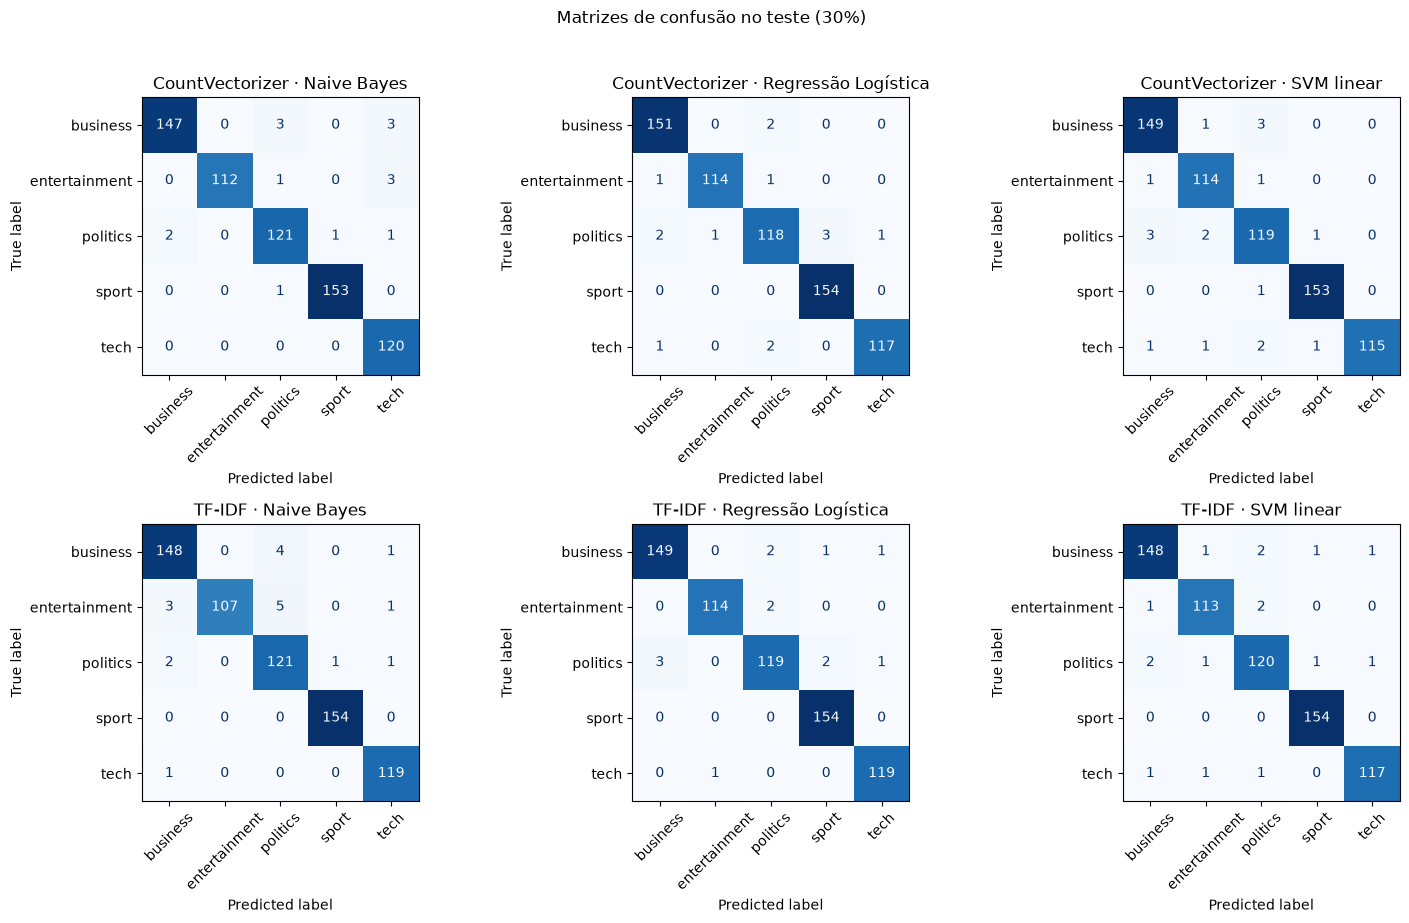

,representação,classificador,acurácia,precisão micro,precisão macro,recall micro,recall macro,F1 micro,F1 macro
1,CountVectorizer,Naive Bayes,0.9775,0.9775,0.9771,0.9775,0.9776,0.9775,0.9771
2,CountVectorizer,Regressão Logística,0.9790,0.9790,0.9795,0.9790,0.9777,0.9790,0.9785
3,CountVectorizer,SVM linear,0.9731,0.9731,0.9730,0.9731,0.9721,0.9731,0.9725
4,TF-IDF,Naive Bayes,0.9716,0.9716,0.9722,0.9716,0.9699,0.9716,0.9706
5,TF-IDF,Regressão Logística,0.9805,0.9805,0.9807,0.9805,0.9801,0.9805,0.9803
6,TF-IDF,SVM linear,0.9760,0.9760,0.9756,0.9760,0.9753,0.9760,0.9755


In [12]:
# c) Classificadores, matrizes de confusão e métricas
# Três classificadores clássicos para texto: Naive Bayes (gera a partir
# de contagens), regressão logística e SVM de kernel linear (ambos
# lineares no espaço da BoW). C=1 e alpha=1 são os padrões; o SVM
# sobe para 8000 iterações porque a formulação dual no Count, com
# muito mais termos do que documentos, não convergia em 1000.
print("c) Treino dos três classificadores nas duas representações")

representations = {
    "CountVectorizer": (X_train_count, X_test_count),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
}

clf_builders = {
    "Naive Bayes": lambda: MultinomialNB(),
    "Regressão Logística": lambda: LogisticRegression(max_iter=1000, random_state=42),
    "SVM linear": lambda: LinearSVC(max_iter=8000, random_state=42),
}


def classification_metrics(y_true, y_pred, rep_name, clf_name):
    return {
        "representação": rep_name,
        "classificador": clf_name,
        "acurácia": accuracy_score(y_true, y_pred),
        "precisão micro": precision_score(y_true, y_pred, average="micro"),
        "precisão macro": precision_score(y_true, y_pred, average="macro"),
        "recall micro": recall_score(y_true, y_pred, average="micro"),
        "recall macro": recall_score(y_true, y_pred, average="macro"),
        "F1 micro": f1_score(y_true, y_pred, average="micro"),
        "F1 macro": f1_score(y_true, y_pred, average="macro"),
    }


rows = []
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row_i, (rep_name, (X_tr, X_te)) in enumerate(representations.items()):
    for col_i, (clf_name, builder) in enumerate(clf_builders.items()):
        model = builder()
        pred = model.fit(X_tr, y_train).predict(X_te)
        rows.append(classification_metrics(y_test, pred, rep_name, clf_name))

        ConfusionMatrixDisplay.from_predictions(
            y_test,
            pred,
            labels=LABELS,
            ax=axes[row_i][col_i],
            colorbar=False,
            cmap="Blues",
        )
        axes[row_i][col_i].set_title(f"{rep_name} · {clf_name}")
        axes[row_i][col_i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Matrizes de confusão no teste (30%)", y=1.02)
plt.tight_layout()
plt.show()

metrics = pd.DataFrame(rows)
metrics.index = metrics.index + 1
display(metrics.round(4))


**d)** Os seis arranjos foram treinados no mesmo holdout estratificado: 1557 textos de treino e 668 de teste, com um vocabulário de 18.160 termos visto só no treino. Isso foi feito pois a lista pede essa partição e pede matrizes de confusão no conjunto de teste, o que combina com um único holdout visível, e não com a média de vários folds. Estratificar mantém no teste as cinco seções na mesma proporção da base (153 business, 116 entertainment, 125 politics, 154 sport e 120 tech). Ajustar CountVectorizer e TF-IDF apenas no treino impede que o IDF e o dicionário “olhem” os documentos que depois serão avaliados.

Os três classificadores cobrem famílias diferentes e usuais em texto. O Naive Bayes gera a partir de contagens. A regressão logística e o SVM linear separam as classes no espaço da bag-of-words. Os hiperparâmetros são os padrões (C=1, suavização de Laplace 1). O SVM recebeu mais iterações porque, no Count, há muito mais termos do que documentos e a formulação dual não fechava em mil passos. Precisão, recall e F1 micro coincidem com a acurácia em todas as linhas da tabela: cada notícia tem um único rótulo, então essas quatro métricas medem a mesma taxa de acerto global. O que muda de uma linha para outra é o macro, que dá o mesmo peso às cinco seções, inclusive à menor.

**Regressão logística**

É o melhor resultado da tabela, com TF-IDF: acurácia 0,9805, precisão macro 0,9807, recall macro 0,9801 e F1 macro 0,9803. A mesma logística no CountVectorizer já chega a 0,9790 de acurácia e 0,9785 de F1 macro. O IDF reduz o peso de stems que aparecem nas cinco mesas e deixa o modelo linear apoiar-se no vocabulário mais típico de cada seção. A diferença entre as duas representações equivale a cerca de um documento a mais certo em 668. Depois do pré-processamento da Lista 1 as classes já estão quase linearmente separáveis; o TF-IDF só afina essa margem.

**Naive Bayes**

A ordem se inverte. Com CountVectorizer a acurácia é 0,9775 e o F1 macro 0,9771, bem perto da logística. Com TF-IDF os números caem para 0,9716 e 0,9706, o pior dos seis arranjos, e é o único em que o recall macro (0,9699) se afasta um pouco mais do micro. O modelo multinomial foi escrito para contagens. Frequências fracionárias e o IDF, que comprime palavras presentes em muitos textos da mesma classe, enfraquecem a hipótese de geração. Na matriz TF-IDF desse classificador a linha de entertainment é a que mais sai da diagonal: a seção com menos exemplos no teste é a que mais sente a reponderação. Quando as features voltam a ser contagens, essa linha se alinha às demais e o Naive Bayes deixa de ser o pior.

**SVM linear**

Com TF-IDF obtém acurácia 0,9760 e F1 macro 0,9755, entre a logística e o Naive Bayes. Com CountVectorizer cai para 0,9731 e 0,9725, o segundo pior da tabela. A margem máxima não supera a logística neste problema: as duas famílias são lineares no mesmo espaço, e a logística já resolve quase todos os 668 casos. O custo aparece no Count, em que a otimização é a mais pesada dos seis treinos. Nas duas matrizes, porém, a linha e a coluna de sport continuam quase limpas, o mesmo padrão dos outros quatro painéis.

**Classes nas matrizes**

Sport é a seção mais fácil em todos os arranjos, com F1 perto de 0,99, coerente com o vocabulário de provas e atletas que a questão 1 já tinha isolado. Politics é a mais difícil, com F1 na casa de 0,95 a 0,96. Os erros saem sobretudo para business e, em menor grau, para tech, a mesma sobreposição lexical que levou o Count a casar a matéria de tinta eleitoral no Quirguistão com um rumor de eleição no Reino Unido. Entertainment e tech quase não se misturam na logística com TF-IDF, embora na questão 1 o Count tivesse ligado a árvore da Tate a um recorde de SMS pelo stem `text`.

No conjunto, trocar o classificador move mais a tabela do que trocar a representação, com uma ressalva: o Naive Bayes precisa das contagens para não ficar em último. A combinação que melhor alinha as duas escolhas é a regressão logística com TF-IDF. Micro e macro permanecem colados porque o desbalanceamento é moderado. No teste, sport tem 154 exemplos e entertainment 116, diferença pequena demais para o macro se descolar da acurácia.

#### 3. Você deverá aplicar dois métodos de modelagem de tópicos sobre uma base textual, utilizando a representação TF-IDF dos textos:
• um método clássico, à sua escolha entre LDA, NMF ou SVD truncado;  
• e o método BERTopic.

a) Defina um número de tópicos apropriado para sua base e justifique a escolha com base em interpretação qualitativa ou métricas de coerência.  
b) Identifique as 5 palavras mais relevantes de cada tópico.  
c) Identifique o tópico mais relevante de 5 documentos quaisquer (você pode representar os tópicos por suas 5 palavras mais relevantes).  
d) Qual método apresentou melhores resultados, na sua opinião? Justifique com resultados/dados.

**a)** Número de tópicos: varredura no NMF e descoberta automática no BERTopic.

a) Escolha do número de tópicos
TF-IDF (textos pré-processados): 2225 × 6412

NMF: varredura de k


,erro de reconstrução,diversidade top-5,pureza vs. categoria
k,,,
4,45.40,1.00,0.760
5,45.17,1.00,0.933
6,45.03,1.00,0.870
7,44.90,1.00,0.884
8,44.78,1.00,0.891
9,44.66,0.98,0.917
10,44.54,0.98,0.930


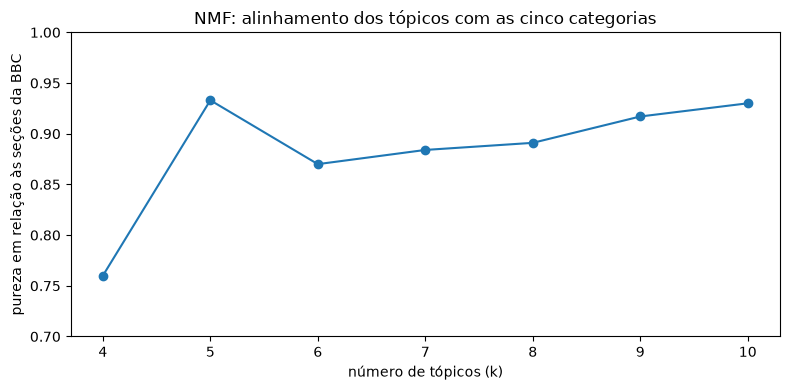

NMF final com k = 5

BERTopic (encoder + c-TF-IDF sobre o texto original). Pode levar cerca de um minuto.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BERTopic encontrou 6 tópicos de conteúdo (além do outlier -1, se existir).


,Topic,Count,Name
0,-1,28,-1_kenteris_iaaf_thanou_conte
1,0,792,0_said_music_film_people
2,1,483,1_said_growth_economy_market
3,2,426,2_mr_said_labour_election
4,3,337,3_england_game_rugby_club
5,4,86,4_roddick_seed_open_nadal
6,5,73,5_indoor_race_world_championships


In [13]:
# a) Número de tópicos: NMF no TF-IDF (k de 4 a 10) e BERTopic livre
print("a) Escolha do número de tópicos")

topic_tfidf = TfidfVectorizer(min_df=5, max_df=0.5)
X_topics = topic_tfidf.fit_transform(news["text_preproc"])
topic_vocab = topic_tfidf.get_feature_names_out()
print(f"TF-IDF (textos pré-processados): {X_topics.shape[0]} × {X_topics.shape[1]}")


def nmf_top_words(components, n=5):
    lines = []
    for row in components:
        idx = row.argsort()[::-1][:n]
        lines.append([topic_vocab[j] for j in idx])
    return lines


sweep_rows = []
for k in range(4, 11):
    model = NMF(n_components=k, random_state=42, init="nndsvd", max_iter=400)
    W = model.fit_transform(X_topics)
    pred = W.argmax(axis=1)
    ct = pd.crosstab(pred, news["category"])
    purity = ct.max(axis=1).sum() / len(news)
    words = nmf_top_words(model.components_, 5)
    n_unique = len({w for topic in words for w in topic})
    sweep_rows.append({
        "k": k,
        "erro de reconstrução": round(model.reconstruction_err_, 2),
        "diversidade top-5": round(n_unique / (5 * k), 2),
        "pureza vs. categoria": round(purity, 3),
    })

sweep_table = pd.DataFrame(sweep_rows).set_index("k")
print("\nNMF: varredura de k")
display(sweep_table)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep_table.index, sweep_table["pureza vs. categoria"], marker="o")
ax.set_xlabel("número de tópicos (k)")
ax.set_ylabel("pureza em relação às seções da BBC")
ax.set_title("NMF: alinhamento dos tópicos com as cinco categorias")
ax.set_xticks(list(sweep_table.index))
ax.set_ylim(0.70, 1.00)
plt.tight_layout()
plt.show()

N_TOPICS = 5
nmf_topics = NMF(n_components=N_TOPICS, random_state=42, init="nndsvd", max_iter=400)
W_nmf = nmf_topics.fit_transform(X_topics)
print(f"NMF final com k = {N_TOPICS}")

print("\nBERTopic (encoder + c-TF-IDF sobre o texto original). Pode levar cerca de um minuto.")
from umap import UMAP

bert_vectorizer = TfidfVectorizer(stop_words="english")
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)
bertopic_model = BERTopic(
    language="english",
    vectorizer_model=bert_vectorizer,
    umap_model=umap_model,
    min_topic_size=40,
    calculate_probabilities=True,
    verbose=False,
)
bert_topics, bert_probs = bertopic_model.fit_transform(news["content"].astype(str).tolist())
bert_info = bertopic_model.get_topic_info()
n_bert = int((bert_info["Topic"] != -1).sum())
print(f"BERTopic encontrou {n_bert} tópicos de conteúdo (além do outlier -1, se existir).")
display(bert_info[["Topic", "Count", "Name"]])


**a)** O método clássico é o NMF sobre o TF-IDF dos 2225 textos já pré-processados (6412 termos, `min_df=5` e `max_df=0,5`). Escolhemos NMF, e não LDA nem SVD truncado, porque a lista pede TF-IDF: o NMF trabalha com matriz não negativa e devolve tópicos aditivos, o LDA espera contagens e o SVD mistura cargas positivas e negativas.

A BBC tem cinco seções, então k=5 é o candidato natural. A tabela da varredura confirma. Com k=4 a pureza cai para 0,760: tech desaparece como tópico próprio. Com k=5 a pureza sobe para **0,933**, o máximo da faixa, a diversidade do top-5 fica em 1,00 (nenhum stem se repete entre tópicos) e o erro de reconstrução é 45,17. A partir de k=6 a pureza cai para 0,870, porque o NMF começa a fatiar business em dois e os documentos da mesma seção se espalham. De k=6 a k=10 o erro quase não se move (45,03 até 44,54) e em k=9 a diversidade já baixa para 0,98. k=10 recupera pureza 0,930, perto de k=5, mas com tópicos repetidos e leitura mais fragmentada. Por isso fixamos **k = 5**.

O BERTopic não recebe k: o HDBSCAN escolhe no espaço do encoder. Na tabela ele devolve **6 tópicos de conteúdo** e um outlier **-1 com 28 documentos** (`kenteris`, `iaaf`, `thanou`, `conte`, o caso de doping grego). Os seis tópicos têm tamanhos muito desiguais: 792 (`said`, `music`, `film`, `people`, `mobile`), 483 (`said`, `growth`, `economy`, `market`, `economic`), 426 (`mr`, `said`, `labour`, `election`, `blair`), 337 (`england`, `game`, `rugby`, `club`, `wales`), 86 (`roddick`, `seed`, `open`, `nadal`, `henman`) e 73 (`indoor`, `race`, `world`, `championships`, `marathon`). A ordem de grandeza é a mesma do NMF, mas o encoder fatia sport em três (rúgbi, tênis, atletismo indoor) e junta cinema, música e tecnologia num único bloco de 792 textos, visível já no top-5 com `film` ao lado de `mobile`. Cinco tópicos continuam sendo o número apropriado para descrever a archive como jornal de cinco mesas. O BERTopic, deixado livre, confirma esse porte e mostra onde a granularidade extra se concentra.

**b)** Cinco palavras mais relevantes de cada tópico.

In [14]:
# b) Cinco palavras mais relevantes de cada tópico
print("b) Cinco palavras mais relevantes de cada tópico")

nmf_word_rows = []
for i, row in enumerate(nmf_topics.components_):
    idx = row.argsort()[::-1][:5]
    nmf_word_rows.append({
        "tópico": i,
        "5 palavras": ", ".join(topic_vocab[j] for j in idx),
    })
print("\nNMF (k = 5)")
display(pd.DataFrame(nmf_word_rows))

bert_word_rows = []
for t in bert_info["Topic"].tolist():
    if t == -1:
        continue
    top5 = bertopic_model.get_topic(t)[:5]
    n_docs = int(bert_info.loc[bert_info["Topic"] == t, "Count"].iloc[0])
    bert_word_rows.append({
        "tópico": t,
        "5 palavras": ", ".join(w for w, _ in top5),
        "n documentos": n_docs,
    })
print("\nBERTopic")
display(pd.DataFrame(bert_word_rows))


b) Cinco palavras mais relevantes de cada tópico

NMF (k = 5)


,tópico,5 palavras
0,0,"game, play, win, england, player"
1,1,"mr, labour, elect, parti, blair"
2,2,"mobil, phone, use, technolog, peopl"
3,3,"film, award, best, star, nomin"
4,4,"growth, economi, bank, rate, us"



BERTopic


,tópico,5 palavras,n documentos
0,0,"said, music, film, people, mobile",792
1,1,"said, growth, economy, market, economic",483
2,2,"mr, said, labour, election, blair",426
3,3,"england, game, rugby, club, wales",337
4,4,"roddick, seed, open, nadal, henman",86
5,5,"indoor, race, world, championships, marathon",73


**c)** Tópico mais relevante de 5 documentos (os mesmos da questão 1).

In [15]:
# c) Tópico mais relevante de 5 documentos (os mesmos da questão 1)
print("c) Tópico mais relevante de 5 documentos")

query_idx = news.groupby("category", sort=True).head(1).index.tolist()


def nmf_assignment(i):
    t = int(W_nmf[i].argmax())
    idx = nmf_topics.components_[t].argsort()[::-1][:5]
    words = ", ".join(topic_vocab[j] for j in idx)
    return t, words, float(W_nmf[i, t])


def bert_assignment(i):
    t = int(bert_topics[i])
    if t == -1:
        return t, "outlier", 0.0
    words = ", ".join(w for w, _ in bertopic_model.get_topic(t)[:5])
    prob = float(bert_probs[i].max()) if bert_probs is not None else 0.0
    return t, words, prob


doc_rows = []
for i in query_idx:
    nmf_t, nmf_w, nmf_s = nmf_assignment(i)
    bert_t, bert_w, bert_p = bert_assignment(i)
    doc_rows.append({
        "título": news.loc[i, "title"],
        "categoria": news.loc[i, "category"],
        "NMF": f"{nmf_t}: {nmf_w}",
        "peso NMF": round(nmf_s, 3),
        "BERTopic": f"{bert_t}: {bert_w}",
        "prob. BERTopic": round(bert_p, 3),
    })

display(pd.DataFrame(doc_rows))


c) Tópico mais relevante de 5 documentos


,título,categoria,NMF,peso NMF,BERTopic,prob. BERTopic
0,Ad sales boost Time Warner profit,business,"4: growth, economi, bank, rate, us",0.111,"1: said, growth, economy, market, economic",0.694
1,Gallery unveils interactive tree,entertainment,"3: film, award, best, star, nomin",0.017,"0: said, music, film, people, mobile",0.708
2,Labour plans maternity pay rise,politics,"1: mr, labour, elect, parti, blair",0.072,"2: mr, said, labour, election, blair",0.438
3,Claxton hunting first major medal,sport,"0: game, play, win, england, player",0.059,"5: indoor, race, world, championships, marathon",1.000
4,Ink helps drive democracy in Asia,tech,"1: mr, labour, elect, parti, blair",0.052,"2: mr, said, labour, election, blair",0.356


**d)** Os dois métodos partem de TF-IDF, mas não lêem a base do mesmo jeito. O NMF fatia a matriz documento-termo pré-processada (stems sem stopwords). O BERTopic primeiro agrupa sentenças no espaço do encoder e só depois nomeia cada grupo com c-TF-IDF sobre o texto original. A pergunta é qual leitura descreve melhor estas 2225 notícias.

**NMF**

Com k=5 a correspondência com as mesas da BBC é quase um a um e a pureza chega a 0,933. Os top-5 não se repetem entre tópicos: sport (`game`, `play`, `win`, `england`, `player`), politics (`mr`, `labour`, `elect`, `parti`, `blair`), tech (`mobil`, `phone`, `use`, `technolog`, `peopl`), entertainment (`film`, `award`, `best`, `star`, `nomin`) e business (`growth`, `economi`, `bank`, `rate`, `us`). Nos cinco documentos da questão 1, três caem no tópico da própria seção: Time Warner em business com peso 0,111, Labour em politics com 0,072 e Claxton em sport com 0,059. A galeria da Tate vai para entertainment, mas com peso **0,017**, residual: o tópico é cinema e prêmios, não museu. A matéria da tinta eleitoral no Quirguistão vai para politics com peso 0,052, o mesmo erro que o CountVectorizer cometeu na questão 1, porque `elect` pesa mais do que vocabulário de tecnologia nesta fatoração.

**BERTopic**

O HDBSCAN devolve 6 tópicos de conteúdo e 28 outliers. Três tópicos são fatias de esporte: rúgbi (`england`, `game`, `rugby`, `club`, `wales`, 337 textos), tênis (`roddick`, `nadal`, `henman`, 86) e atletismo indoor (`indoor`, `race`, `world`, `championships`, `marathon`, 73). O encoder faz isso melhor do que o NMF: Claxton, que disputa o Europeu indoor, cai no tópico 5 com probabilidade **1,000**, e não no bloco genérico de `game` / `england`. Business e politics aparecem nítidos (tópico 1 com 483 textos, probabilidade 0,694 em Time Warner; tópico 2 com 426 textos, probabilidade 0,438 em Labour). O custo está no tópico 0, com **792 documentos**: `said`, `music`, `film`, `people`, `mobile` misturam entertainment e tech. A árvore da Tate cai aí com probabilidade 0,708. `said` lidera os tópicos 0, 1 e 2 porque o BERTopic vê o texto cru da BBC, em que esse verbo jornalístico sobrevive, enquanto o NMF opera nos stems já sem stopwords da Lista 1. A tinta no Quirguistão também cai em politics (probabilidade 0,356). O outlier -1 isola o caso Kenteris/Thanou (IAAF), um recorte fino que o NMF com k=5 não abre.

**Documentos**

Time Warner: os dois métodos apontam economia (`growth` / `bank` no NMF, `growth` / `economy` / `market` no BERTopic). Gallery: os dois apontam cultura, mas o NMF quase não ativa o tópico (0,017) e o BERTopic a coloca no bloco misturado com `mobile`. Labour: politics nos dois. Claxton: sport nos dois, com o BERTopic mais específico (indoor). Ink: politics nos dois, o mesmo viés de vocabulário eleitoral da questão 1.

**Qual método é melhor nesta base**

O NMF apresentou o melhor resultado para o que a base é: um jornal de cinco seções. A evidência é a pureza 0,933, a diversidade 1,00 do top-5 e o alinhamento palavra a palavra com business, entertainment, politics, sport e tech. O BERTopic é mais fino dentro de sport (Claxton com probabilidade 1,0 no indoor) e isola o doping grego, mas paga com um tópico genérico de 792 textos, com `said` repetido nas listas e com tech absorvido por cinema e música. Se o objetivo fosse descobrir subtemas (tênis versus atletismo indoor), o BERTopic seria a escolha. Para descrever esta archive e conversar com as questões 1 e 2, o NMF com k=5 é o modelo que melhor organiza o vocabulário.